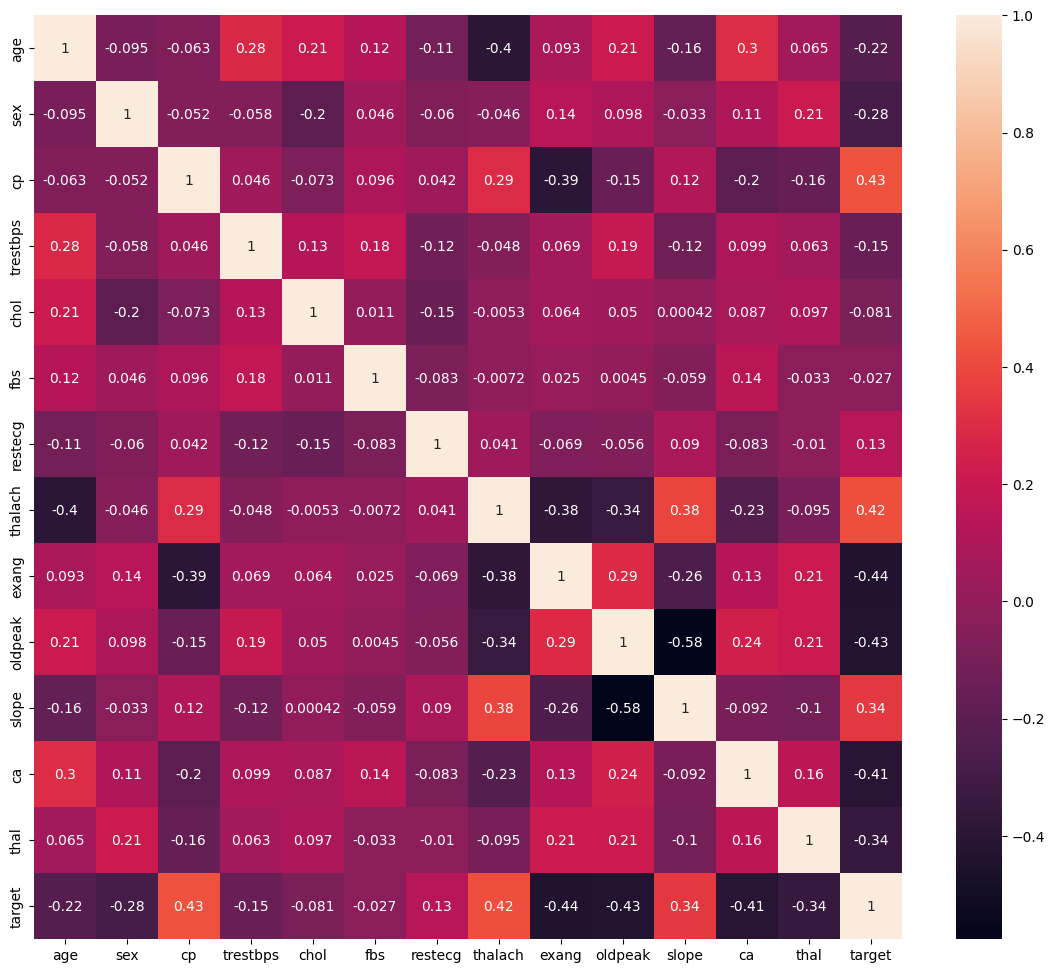

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,cross_val_score,StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

data=pd.read_csv('heart.csv')
df=pd.DataFrame(data)
df=df.drop_duplicates()
df["age"] = pd.to_numeric(df["age"])
x=df.drop("target",axis=1)
y=df["target"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)
# Increased max_iter to fix ConvergenceWarning
model=LogisticRegression(max_iter=5000)
model.fit(x_train_scaled,y_train)
y_pred=model.predict(x_test_scaled)
accuracy=accuracy_score(y_test,y_pred)
cv=StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
# Use scaled data for cross-validation to avoid warnings
scores=cross_val_score(
    model,
    x_train_scaled,
    y_train,
    cv=cv,
    scoring='accuracy'
)
plt.figure(figsize=(14,12))
sns.heatmap(
    df.corr(),
    annot=True
)
plt.show()

In [48]:
x=df.drop(["restecg","fbs","chol","target"],axis=1)
y=df["target"]
cv=StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
# Updated to use x_train_scaled
scores=cross_val_score(
    model,
    x_train_scaled,
    y_train,
    cv=cv,
    scoring='accuracy'
)
print(scores.mean())

0.817517006802721


In [43]:
cv=StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
# Updated to use x_train_scaled
scores=cross_val_score(
    model,
    x_train_scaled,
    y_train,
    cv=cv,
    scoring='f1'
)
print(scores.mean())

0.8341740715424926


In [44]:
from sklearn.model_selection import GridSearchCV
params = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100]
}
grid=GridSearchCV(
    model,
    params,
    cv=cv,
    scoring='accuracy'
)
# Updated to use x_train_scaled to prevent ConvergenceWarning
grid.fit(x_train_scaled,y_train)
print(grid.best_params_)
print(grid.best_score_)

{'C': 0.1}
0.8300170068027211


In [45]:
cv=StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
model1=SVC()
params = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", "auto", 0.01, 0.1, 1],
    "kernel": ["linear", "rbf"]
}
# Using scaled data for faster convergence
scores=cross_val_score(
    model1,
    x_train_scaled,
    y_train,
    cv=cv,
    scoring='accuracy'
)
grid=GridSearchCV(
    model1,
    params,
    cv=cv,
    scoring='accuracy'
)
grid.fit(x_train_scaled,y_train)
print(f"Best Params: {grid.best_params_}")
print(f"Best Score: {grid.best_score_}")

Best Params: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Best Score: 0.8258503401360544


In [49]:
x=df.drop(["restecg","fbs","chol","target"],axis=1)
y=df["target"]
cv=StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
# Updated to use x_train_scaled to ensure consistency and speed
scores=cross_val_score(
    model,
    x_train_scaled,
    y_train,
    cv=cv,
    scoring='accuracy'
)
from sklearn.model_selection import GridSearchCV
params = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100]
}
grid=GridSearchCV(
    model,
    params,
    cv=cv,
    scoring='f1'
)
grid.fit(x_train_scaled,y_train)
print(grid.best_params_)
print(grid.best_score_)

{'C': 0.1}
0.8500689122871139
